# 1. Imports

In [18]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd 
import seaborn as sns

#Sklearn bibliotheken
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error #RMSE, MAE, r2 gebruiken
from sklearn.pipeline import Pipeline #niet heel belangrijk, zet samen standard scaler en linear svc
from sklearn.preprocessing import StandardScaler #standardisatie: gem 0, std 1 
from sklearn.svm import LinearSVC
from sklearn.svm import LinearSVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# 2. Data

## 2.1 Load

In [19]:
pieken = pd.read_csv("CuNPs_Size.csv")
median_size = np.median(pieken['Size_1[nm]'])
pieken['Klasse_size']=(pieken["Size_1[nm]"]>median_size).astype(int)

X = pieken[["Cu_conc[M]","Temperature[°C]","Time[min]"]]
y = pieken["Klasse_size"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [20]:
def parameter_sweep(X_scaled, y, param_grid):
    loo = LeaveOneOut()
    results = []
    ## Dubbele for loop om alle hyperparameter combinaties te doorlopen
    for C in param_grid["C"]: ## Hier aanpassen naar hyperparameters voor SVM
        for gamma in param_grid["gamma"]: ## Hier aanpassen naar hyperparameters voor SVM
            scores = []
            ## For loop die LOO-CV doorloopt voor volledige dataset
            for train_idx, val_idx in loo.split(X):
                X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
                y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
                ## Definieren van model dat getrained moet worden. Hier random forrest vervangen door SVM + juiste hyperparameters
                model = SVC(kernel='rbf', C=C, gamma=gamma, class_weight='balanced')
                model.fit(X_train, y_train)
                pred = model.predict(X_val)
                scores.append(accuracy_score(y_val, pred))
            ## Scores van verschillende hyperparameter sets opslaan. Aanpassen naar SVM hyperparameters
            results.append({
                "C": C,
                "gamma": gamma,
                "mean_score": np.mean(scores),
                "std_score": np.std(scores)
            })
    return results

## 2.1 Grid definiëren

In [ ]:
param_grid = {
    "C":[0.1, 1, 10, 100],
    "gamma": [0.001, 0.01, 0.1, 1]}

# 3. Hyper parameter tuning

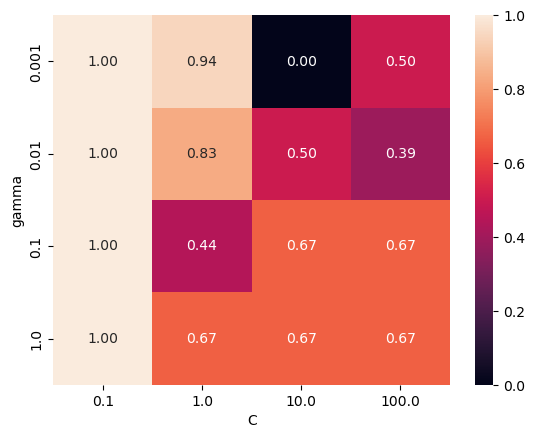

In [23]:
results = parameter_sweep(X_scaled, y, param_grid)
results = pd.DataFrame(results)## Zet results variabele om naar een dataframe om er makkelijker mee te kunnen werken

heat_plot = results.pivot(index="gamma", columns="C", values="mean_score") 
sns.heatmap(heat_plot, annot=True, fmt=".2f")
plt.show()


# 4. Training

In [25]:
all_results=[]

for i in range(100): ### Aantal modellen in ensemble
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, 
                                                        test_size=0.2, stratify=y)
    model = SVC(C=1.0,
                gamma=0.01,
                class_weight='balanced')
    svc = model.fit(X_train, y_train)
    predictions = svc.predict(X_test)
    
    for idx, pred in zip(y_test.index, predictions):
        all_results.append({
            "run":i,
            "index":idx,
            "y_true":y.loc[idx], 
            "y_pred":pred 
        })

df_results=pd.DataFrame(all_results)

y_pred = model.predict(X_test)

In [26]:
ensemble_predictions=(df_results.groupby("index")["y_pred"]
    .agg(lambda x: x.value_counts().idxmax()))

# True labels 
y_true_final = (
    df_results
    .drop_duplicates(subset="index")
    .set_index("index")["y_true"])

# Accuracy berekenen
ensemble_acc = accuracy_score(y_true_final, ensemble_predictions)
print("Ensemble accuracy:", ensemble_acc)

Ensemble accuracy: 0.6666666666666666


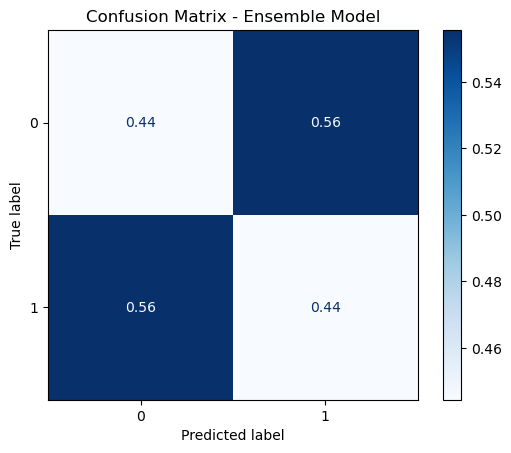

In [27]:
#duidelijke plot en labels + genormaliseerd + matching indices
common_idx = y_true_final.index.intersection(ensemble_predictions.index)
ConfusionMatrixDisplay.from_predictions(
    y_true_final.loc[common_idx],
    ensemble_predictions.loc[common_idx],
    cmap="Blues",
    normalize="true" 
)

plt.title("Confusion Matrix - Ensemble Model")
plt.show()

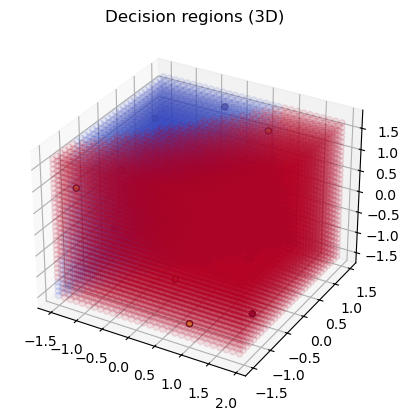

In [31]:
# grid maken
xx, yy, zz = np.meshgrid(
    np.linspace(X_scaled[:,0].min(), X_scaled[:,0].max(), 30),
    np.linspace(X_scaled[:,1].min(), X_scaled[:,1].max(), 30),
    np.linspace(X_scaled[:,2].min(), X_scaled[:,2].max(), 30)
)

grid = np.c_[xx.ravel(), yy.ravel(), zz.ravel()]
preds = model.predict(grid)

# plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(grid[:,0], grid[:,1], grid[:,2],
           c=preds, alpha=0.1, cmap='coolwarm')

ax.scatter(X_scaled[:,0], X_scaled[:,1], X_scaled[:,2],
           c=y, edgecolor='k')

plt.title("Decision regions (3D)")
plt.show()

In [28]:
#X = pieken[["Cu_conc[M]","Temperature[°C]","Time[min]"]]
#y = pieken["klasse_size"]

#X_train, X_test, y_train, y_test = train_test_split(X,y , random_state=42, test_size=0.2, shuffle=True)

In [6]:
#model_class = SVC(kernel='rbf')
#scaler = StandardScaler()
#X_train_scaled = scaler.fit_transform(X_train)
#X_test_scaled = scaler.fit_transform(X_test)

In [29]:
#parameter_grid = {'C': [0.01, 0.1, 1, 10, 100],'gamma': [0.01, 0.1, 1, 10, 100]}

#grid = GridSearchCV(model_class, parameter_grid, cv=3)
#grid.fit(X_train_scaled,y_train)

In [30]:
# cross validation scores
#scores = cross_val_score(model, X_train_scaled, y_train, cv=3)

#print(scores)
#print("Gemiddelde score:", scores.mean())

In [ ]:
#print("best parameters", grid.best_params_)

In [ ]:
#svm_clf = SVC(kernel='rbf',gamma=0.1, C=10)
#svm_clf.fit(X_train_scaled, y_train)

In [ ]:
#test_accuracy=svm_clf.score(X_test_scaled,y_test) #overeenkomen van X-test en y_test
#print(test_accuracy)

In [ ]:
#y_pred = svm_clf.predict(X_test_scaled)

#ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
#plt.show()

In [ ]:
#predicted=svm_clf.predict(X_test)
#print(y_test) 

In [ ]:
#test_accuracy=svm_clf.score(X_test,y_test) #overeenkomen van X-test en y_test
#print(test_accuracy)